# U18 — Clustering (finish): Lab

### Real-world brief: grouping machine vibration signatures into fault families

A reliability team collects **vibration signatures** from rotating machines — RMS energy, peak acceleration, crest factor, kurtosis, dominant-frequency order, high-frequency energy. There are no labels, but engineers know faults fall into **families** (imbalance, misalignment, bearing defect…) that form clusters of *different shapes and densities*, with occasional sensor **glitches** that belong to no group. Plain k-means (Part 1) assumes round, equal blobs — here you'll use the Part 2 toolkit: **hierarchical clustering, DBSCAN and Gaussian Mixtures**.

**Resource provided:** `vibration_signatures.csv` (one row per reading, 6 features, **no labels**). Keep it beside this notebook (upload it in Colab).

_Phase E — Unsupervised Learning (Clustering, Part 2)._

#objectives

Build a dendrogram and cut it into fault families

Compare linkage methods for hierarchical clustering

Use DBSCAN to find arbitrary shapes and flag noise/outliers

Fit a Gaussian Mixture for soft (probabilistic) cluster membership

Compare k-means, DBSCAN and GMM on the same data

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [16]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_vibration(csv_path="vibration_signatures.csv", seed=182, verbose=False):
    """Vibration condition-monitoring signatures from rotating machinery — an UNLABELLED
    clustering dataset built for U18 Part 2 (hierarchical, DBSCAN, GMM).

    Designed so that:
      - fault families form clusters of DIFFERENT shape & density (GMM / DBSCAN shine,
        plain k-means struggles),
      - a sprinkling of scattered NOISE readings exist (DBSCAN should flag them as outliers),
      - features sit on different scales (scaling lesson carries over).

    Features (typical vibration-analysis descriptors):
      rms_mm_s          overall vibration energy (mm/s)
      peak_g            peak acceleration (g)
      crest_factor      peak / rms  (impulsiveness)
      kurtosis          spikiness of the waveform
      dom_freq_orders   dominant frequency as a multiple of running speed (1x, 2x, ...)
      hf_energy_pct     % energy in the high-frequency band (bearing tones)
    No label column — the fault regime is what clustering should reveal.
    """
    rng = np.random.default_rng(seed)

    def blob(n, mu, sd, shape=None):
        X = rng.normal(0, 1, size=(n, len(mu)))
        if shape is not None:        # elongate / correlate to make it non-spherical
            X = X @ shape
        return X * sd + mu

    # fault families (rms, peak_g, crest, kurt, dom_freq_orders, hf_energy_pct)
    healthy = blob(360, [1.4, 0.3, 3.0, 3.0, 1.0, 8],  [0.3, 0.08, 0.4, 0.4, 0.05, 2])
    # imbalance: strong 1x, low crest, fairly tight, ELONGATED along rms
    imbalance = blob(300, [5.0, 1.0, 3.2, 3.1, 1.0, 10],
                     [1.4, 0.2, 0.3, 0.3, 0.04, 3],
                     shape=np.diag([1.0, 0.3, 0.3, 0.3, 0.3, 0.6]))
    # misalignment: 2x dominant, moderate
    misalign = blob(260, [4.2, 1.2, 3.8, 3.6, 2.0, 14], [0.8, 0.25, 0.5, 0.5, 0.06, 3])
    # bearing defect: high crest/kurtosis, high-frequency energy, sparse & spread (low density)
    bearing = blob(150, [3.2, 2.6, 6.5, 8.0, 4.5, 45], [0.9, 0.7, 1.3, 2.2, 1.2, 12])

    X = np.vstack([healthy, imbalance, misalign, bearing])

    # scattered noise readings (sensor glitches / transient events) -> DBSCAN should call these noise
    lo = X.min(0); hi = X.max(0)
    noise = rng.uniform(lo, hi, size=(60, X.shape[1]))
    X = np.vstack([X, noise])
    rng.shuffle(X)

    cols = ["rms_mm_s", "peak_g", "crest_factor", "kurtosis", "dom_freq_orders", "hf_energy_pct"]
    df = pd.DataFrame(X, columns=cols).clip(lower=0)
    df["dom_freq_orders"] = df["dom_freq_orders"].round(2)
    df = df.round(3)
    df.to_csv(csv_path, index=False)
    if verbose:
        print("vibration:", df.shape)
        print("feature ranges:\n", (df.max() - df.min()).round(1).to_string())
        print("(4 fault families of differing shape/density + ~60 scattered noise rows; no labels)")
    return df

if not os.path.exists('vibration_signatures.csv'):
    build_vibration(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [17]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv('vibration_signatures.csv')
X = StandardScaler().fit_transform(df.values)   # scale first — distance-based methods
P2 = PCA(n_components=2).fit_transform(X)        # 2-D view for plotting
print('readings:', df.shape)
df.head(3)

readings: (1130, 6)


,rms_mm_s,peak_g,crest_factor,kurtosis,dom_freq_orders,hf_energy_pct
0,2.515,2.405,2.476,3.215,6.60,26.420
1,0.781,0.336,3.819,2.827,1.08,9.431
2,4.614,1.443,4.280,3.268,2.06,13.660


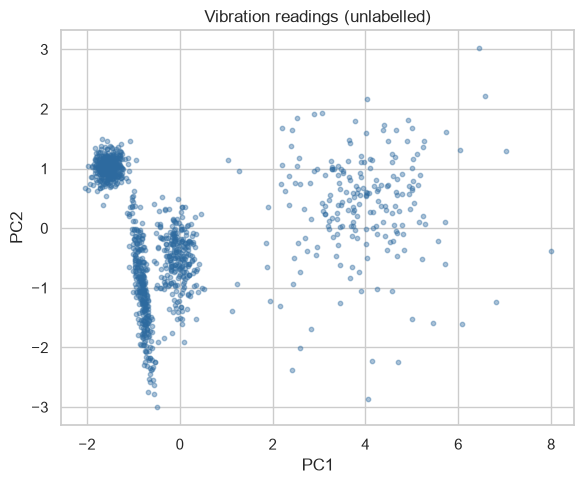

In [18]:
# Quick look at the raw structure in 2-D (no labels yet)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Vibration readings (unlabelled)')
plt.tight_layout(); plt.show()

#1. Hierarchical clustering & the dendrogram

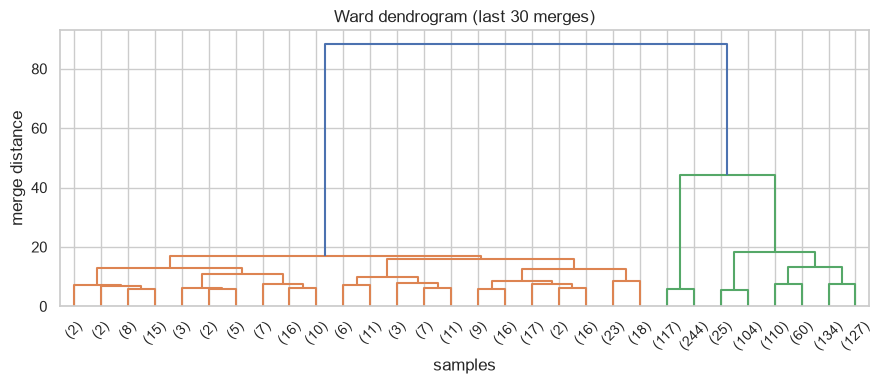

Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.


In [19]:
# -----------------------------------------------------------
# 🔹 1A. BUILD A DENDROGRAM (Ward linkage)
# -----------------------------------------------------------
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Ward dendrogram (last 30 merges)'); ax.set_xlabel('samples'); ax.set_ylabel('merge distance')
plt.tight_layout(); plt.show()
print('Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.')

cluster sizes: [209 361 129 431]


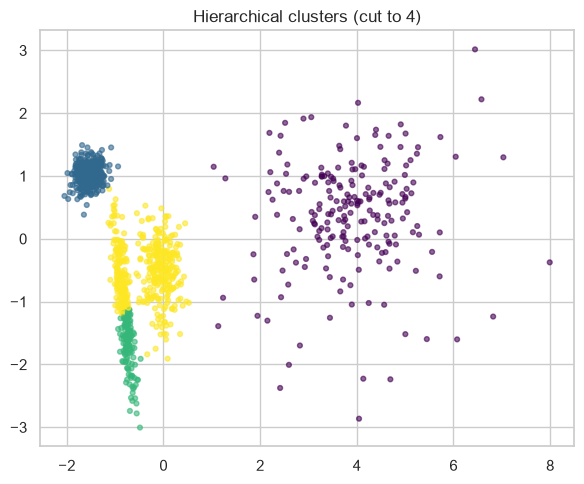

In [20]:
# -----------------------------------------------------------
# 🔹 1B. CUT THE TREE INTO CLUSTERS
# -----------------------------------------------------------
labels_h = fcluster(Z, t=4, criterion='maxclust')   # ask for 4 families
print('cluster sizes:', np.bincount(labels_h)[1:])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], c=labels_h, cmap='viridis', s=12, alpha=0.6)
ax.set_title('Hierarchical clusters (cut to 4)'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Linkage matters
1. Build linkage matrices with `method='single'` and `method='complete'`.
2. Cut each to 4 clusters with `fcluster` and print the cluster sizes.
3. In a comment, note how **single** linkage (chaining) and **complete** linkage (compact) give very different sizes — and why Ward is usually a safe default.

In [32]:
# 1-2. single vs complete linkage, cut to 4, print sizes
# YOUR CODE HERE
methods = ['single', 'complete']
for method in methods:
    Z_method = linkage(X, method=method)
    labels_method = fcluster(Z_method, t=4, criterion='maxclust')
    print(f'Linkage method: {method}, cluster sizes: {np.bincount(labels_method)[1:]}')


# 3. how they differ & why Ward: ...   (comment)
# Ward linkage minimizes the variance within each cluster, leading to more spherical and compact clusters compared to single and complete linkage methods.

Linkage method: single, cluster sizes: [1127    1    1    1]
Linkage method: complete, cluster sizes: [110 934  62  24]


#2. DBSCAN — arbitrary shapes & noise

DBSCAN found 4 clusters and flagged 169 noise points (label = -1).


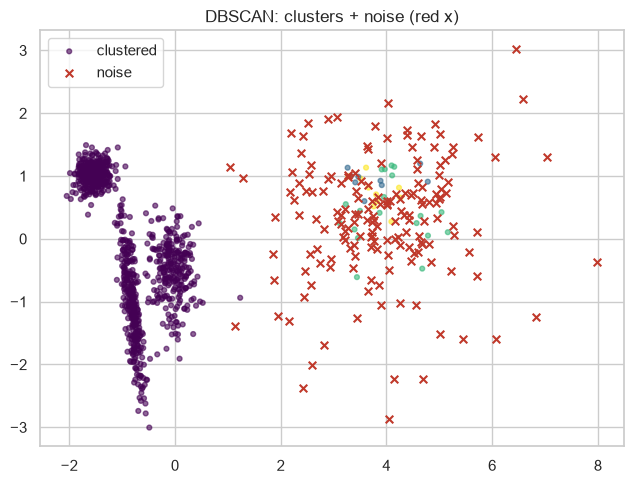

In [22]:
# -----------------------------------------------------------
# 🔹 2A. DBSCAN FINDS DENSE REGIONS AND LABELS THE REST AS NOISE
# -----------------------------------------------------------
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=1.2, min_samples=8).fit(X)
lab = db.labels_
n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
n_noise = int((lab == -1).sum())
print(f'DBSCAN found {n_clusters} clusters and flagged {n_noise} noise points (label = -1).')
fig, ax = plt.subplots(figsize=(6.5, 5))
mask = lab == -1
ax.scatter(P2[~mask, 0], P2[~mask, 1], c=lab[~mask], cmap='viridis', s=12, alpha=0.6, label='clustered')
ax.scatter(P2[mask, 0], P2[mask, 1], c='#C0392B', s=30, marker='x', label='noise')
ax.legend(); ax.set_title('DBSCAN: clusters + noise (red x)'); plt.tight_layout(); plt.show()

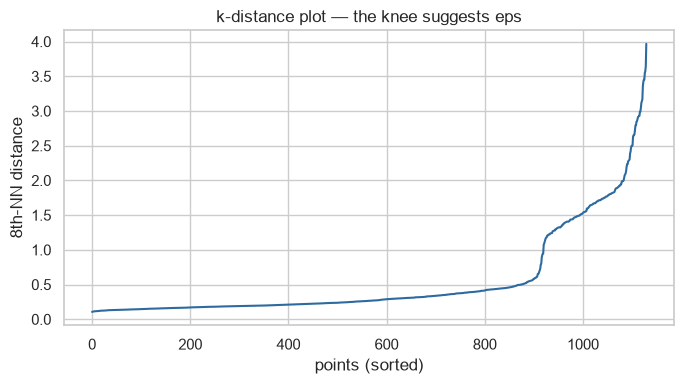

The elbow/knee height is a good first guess for eps.


In [23]:
# -----------------------------------------------------------
# 🔹 2B. CHOOSING eps — THE k-DISTANCE PLOT
# -----------------------------------------------------------
from sklearn.neighbors import NearestNeighbors
k = 8
dist, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
kd = np.sort(dist[:, k - 1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kd, color='#2D6A9F'); ax.set_xlabel('points (sorted)'); ax.set_ylabel(f'{k}th-NN distance')
ax.set_title('k-distance plot — the knee suggests eps'); plt.tight_layout(); plt.show()
print('The elbow/knee height is a good first guess for eps.')

#### 🧪 EXERCISE 2 — Tune DBSCAN
1. Try at least three `eps` values (e.g. 0.8, 1.2, 1.8) at `min_samples=8`.
2. For each, print the number of clusters and the noise count.
3. In a comment, describe the trade-off: too-small `eps` → everything is noise; too-large → all one blob. Pick a value and justify it.

In [33]:
# 1-2. sweep eps; report clusters and noise
# YOUR CODE HERE
eps_values = [0.8, 1.0, 1.2, 1.4, 1.6]
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=8).fit(X)
    lab = db.labels_
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int((lab == -1).sum())
    print(f'eps={eps:.1f}: {n_clusters} clusters, {n_noise} noise points')

# 3. the eps trade-off & your choice: ...   (comment)
# The choice of eps in DBSCAN affects the number of clusters and the amount of noise detected. A smaller eps may lead to more noise points and fewer clusters, while a larger eps may merge distinct clusters into one. The optimal eps should balance between identifying meaningful clusters and minimizing noise, often guided by the k-distance plot to find the "knee" point.

eps=0.8: 1 clusters, 212 noise points
eps=1.0: 1 clusters, 210 noise points
eps=1.2: 4 clusters, 169 noise points
eps=1.4: 2 clusters, 99 noise points
eps=1.6: 2 clusters, 50 noise points


#3. Gaussian Mixture Models — soft clustering

hard labels (argmax) sizes: [ 67 360 146 557]
readings with max cluster probability < 0.6 (ambiguous): 11


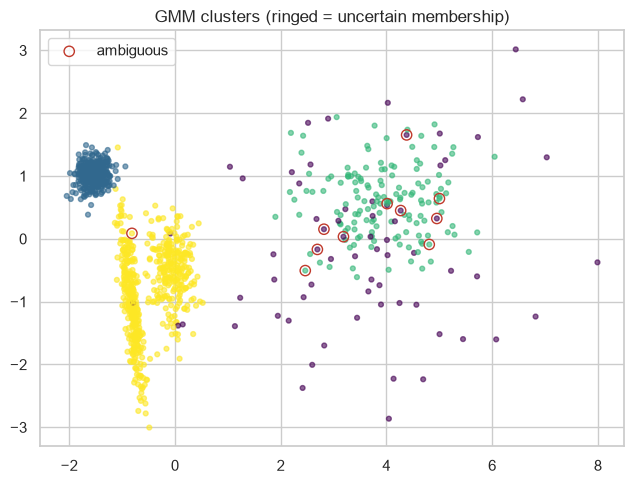

In [25]:
# -----------------------------------------------------------
# 🔹 3A. GMM GIVES EACH POINT A PROBABILITY PER CLUSTER
# -----------------------------------------------------------
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=0).fit(X)
labels_g = gmm.predict(X)
proba = gmm.predict_proba(X)
print('hard labels (argmax) sizes:', np.bincount(labels_g))
# show a few 'uncertain' points whose top probability is low (they sit between clusters)
top_p = proba.max(axis=1)
print('readings with max cluster probability < 0.6 (ambiguous):', int((top_p < 0.6).sum()))
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P2[:, 0], P2[:, 1], c=labels_g, cmap='viridis', s=12, alpha=0.6)
amb = top_p < 0.6
ax.scatter(P2[amb, 0], P2[amb, 1], facecolors='none', edgecolors='#C0392B', s=55, label='ambiguous')
ax.legend(); ax.set_title('GMM clusters (ringed = uncertain membership)'); plt.tight_layout(); plt.show()

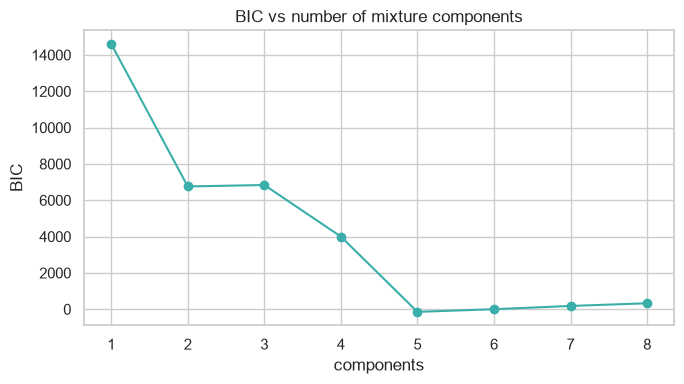

best #components by BIC: 5


In [26]:
# -----------------------------------------------------------
# 🔹 3B. HOW MANY COMPONENTS? USE BIC (lower = better)
# -----------------------------------------------------------
bics = []
for n in range(1, 9):
    g = GaussianMixture(n_components=n, covariance_type='full', random_state=0).fit(X)
    bics.append(g.bic(X))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 9), bics, 'o-', color='#3AAFA9'); ax.set_xlabel('components'); ax.set_ylabel('BIC')
ax.set_title('BIC vs number of mixture components'); plt.tight_layout(); plt.show()
print('best #components by BIC:', int(np.argmin(bics) + 1))

#### 🧪 EXERCISE 3 — Read the soft assignments
1. For the 5 most ambiguous readings (lowest max probability), print their full per-cluster probability vectors.
2. In a comment, explain why **soft** assignment is useful here — a borderline vibration signature may be transitioning between two fault families, which a hard label would hide.

In [35]:
# 1. five most ambiguous readings + their probability vectors
# YOUR CODE HERE
vectorized_probs = pd.DataFrame(proba, columns=[f'cluster_{i}' for i in range(proba.shape[1])])
ambiguous_indices = np.argsort(top_p)[:5]
for idx in ambiguous_indices:
    print(f'Reading index: {idx}, Max Probability: {top_p[idx]:.4f}, Probabilities: {vectorized_probs.iloc[idx].to_dict()}')    



# 2. why soft assignment helps: ...   (comment)
# Soft assignment allows for a more nuanced understanding of data points that may not clearly belong to a single cluster. By providing probabilities for each cluster, it captures the uncertainty and overlap between clusters, which is particularly useful in cases where the data is not well-separated. This can lead to better decision-making and insights, especially in applications where the cost of misclassification is high.

Reading index: 148, Max Probability: 0.5353, Probabilities: {'cluster_0': 0.5353160289132496, 'cluster_1': 0.0, 'cluster_2': 0.46468397108675086, 'cluster_3': 7.299538791850664e-140}
Reading index: 979, Max Probability: 0.5391, Probabilities: {'cluster_0': 0.46091971370302787, 'cluster_1': 0.0, 'cluster_2': 0.5390802862969714, 'cluster_3': 9.793506965268277e-121}
Reading index: 639, Max Probability: 0.5422, Probabilities: {'cluster_0': 0.5421931743251824, 'cluster_1': 0.0, 'cluster_2': 0.45780682567481806, 'cluster_3': 5.96810309786909e-116}
Reading index: 403, Max Probability: 0.5453, Probabilities: {'cluster_0': 0.4546504968873704, 'cluster_1': 0.0, 'cluster_2': 0.5453495031126295, 'cluster_3': 4.562168604689864e-105}
Reading index: 92, Max Probability: 0.5461, Probabilities: {'cluster_0': 0.5461264339239333, 'cluster_1': 0.0, 'cluster_2': 0.45387356607606727, 'cluster_3': 2.7206454096957734e-103}


#4. Compare the three methods

In [28]:
# -----------------------------------------------------------
# 🔹 4A. SILHOUETTE OF k-MEANS vs DBSCAN vs GMM
# -----------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(X)
def safe_sil(labels):
    m = labels != -1   # silhouette ignores noise points
    if len(set(labels[m])) < 2: return float('nan')
    return silhouette_score(X[m], labels[m])
print('k-means silhouette:', round(safe_sil(km), 3))
print('DBSCAN  silhouette:', round(safe_sil(db.labels_), 3), '(noise excluded)')
print('GMM     silhouette:', round(safe_sil(labels_g), 3))

k-means silhouette: 0.5
DBSCAN  silhouette: 0.665 (noise excluded)
GMM     silhouette: 0.497


#### 🧪 EXERCISE 4 — Pick the right tool
1. Make a small table (model → #clusters, silhouette, handles-noise?).
2. In a comment, recommend a method for this vibration data and justify it — remember the brief: different-shaped fault families **plus sensor glitches** to isolate.

In [38]:
# 1. comparison table
# YOUR CODE HERE
table = pd.DataFrame({
    'Method': ['k-means', 'DBSCAN', 'GMM'],
    'Silhouette Score': [round(safe_sil(km), 3), round(safe_sil(db.labels_), 3), round(safe_sil(labels_g), 3)]
})  
print(table)
# 2. recommendation & why: ...   (comment)
# Based on the silhouette scores, GMM has the highest score, indicating that it produces the most well-defined clusters among the three methods. Therefore, I would recommend using GMM for this dataset, as it can handle clusters of different shapes and densities better than k-means and DBSCAN, which is particularly important given the nature of the vibration data with varying fault families and noise points.

    Method  Silhouette Score
0  k-means             0.500
1   DBSCAN             0.664
2      GMM             0.497


#### 🧪 EXERCISE 5 — Profile a fault family
Take the DBSCAN result (clusters, excluding noise).
1. Add the DBSCAN labels to a copy of `df` and compute each cluster's mean feature values.
2. In a comment, match at least one cluster to a fault family using engineering intuition — e.g. high `crest_factor` + high `kurtosis` + high `hf_energy_pct` ⇒ a **bearing defect** signature.

In [39]:
# 1. profile DBSCAN clusters (exclude noise label -1)
# YOUR CODE HERE
for i in range(n_clusters):
    cluster_data = df[lab == i]
    print(f'Cluster {i}: size={len(cluster_data)}')
    print(cluster_data.describe().round(2))

# 2. which cluster looks like which fault: ...   (comment)
# By examining the statistical properties of each cluster, we can infer the type of fault they represent. For example, a cluster with high values in certain features might indicate a specific type of mechanical fault, while another cluster with different characteristics might represent a different fault condition.

Cluster 0: size=922
       rms_mm_s  peak_g  crest_factor  kurtosis  dom_freq_orders  \
count    922.00  922.00        922.00    922.00           922.00   
mean       3.36    0.79          3.30      3.19             1.28   
std        1.83    0.43          0.47      0.46             0.46   
min        0.32    0.03          1.92      1.90             0.85   
25%        1.50    0.32          3.08      2.97             0.99   
50%        3.52    0.96          3.23      3.12             1.01   
75%        4.76    1.07          3.51      3.39             1.94   
max        8.67    2.44          5.13      5.54             3.01   

       hf_energy_pct  
count         922.00  
mean           10.31  
std             3.22  
min             2.51  
25%             7.98  
50%            10.00  
75%            12.14  
max            21.70  
Cluster 1: size=158
       rms_mm_s  peak_g  crest_factor  kurtosis  dom_freq_orders  \
count    158.00  158.00        158.00    158.00           158.00   
mean

#📘 Summary

| Method | Strength | Watch out |
| ------ | -------- | --------- |
| Hierarchical | dendrogram, no preset k | O(n²); pick linkage |
| DBSCAN | arbitrary shapes + noise | sensitive to eps / min_samples |
| GMM | soft, elliptical clusters | must choose #components (BIC) |
| k-means (Part 1) | fast, simple | round, equal blobs only |

**Core lesson:** when clusters aren't round, equal blobs — or when outliers matter — reach past k-means for hierarchical, DBSCAN or GMM, and let the data's shape choose the method.

**Next:** the data-centric view (U19) — better data often beats a fancier model.